# Assignment 2 of the Research track 2 course

In [ ]:
import rospy
import actionlib
from geometry_msgs.msg import PoseStamped

from nav_msgs.msg import Odometry 
from sensor_msgs.msg import LaserScan 
from std_msgs.msg import Header
from actionlib_msgs.msg import GoalStatus

from IPython.display import display
from ipywidgets import IntText, Button, HBox, VBox, Label

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib notebook

import assignment_2_2024.msg

In [ ]:
# Initializing the ROS node
if not rospy.core.is_initialized():
    rospy.init_node('jupyter_client_node', anonymous=True)

# Creating the action client
client = actionlib.SimpleActionClient('reaching_goal', assignment_2_2024.msg.PlanningAction)
client.wait_for_server()

current_feedback = None 

robot_position = (0.0, 0.0) 
obstacle_dist = float('inf') 

# Variables to store how many targets I've reached or not
targets_reached = 0
targets_failed = 0

# Arrays to memorize the trajectory
traj_x = []
traj_y = []

# Adding labels to print status, position and distance from obstacles
status_label = Label(value = "")
position_label = Label(value="Robot position: (0.00, 0.00)")
obstacle_label = Label(value="Closest obstacle: N/A")

[INFO] [1746609543.935163, 2148.531000]: Target reached!
[INFO] [1746609567.455407, 2166.021000]: Target not reached!
[INFO] [1746610088.875182, 2566.355000]: Target not reached!


In [ ]:
# Function to plot the chart of the goals status
def update_goal_chart():
    bar_ax.clear()
    bar_ax.bar(['Targets reached', 'Targets failed'], [targets_reached, targets_failed], color = ['green', 'red'])
    bar_ax.set_ylim(0, max(1.5, targets_reached + 0.5, targets_failed + 0.5))
    bar_ax.set_title("Goal Outcomes")
    bar_ax.set_ylabel("Count")

# Function to update the robot position graph
def update_graph(frame):
    ax.clear()
    ax.plot(traj_x, traj_y, 'b-', label = 'Trajectory')
    if traj_x and traj_y:
        ax.plot(traj_x[-1], traj_y[-1], 'ro', label='Current Position')
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_title('Robot Position in real-time')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)

    update_goal_chart()

In [ ]:
# Function for odom callback
def odom_callback(msg): 
    global robot_position, traj_x, traj_y
    x =  msg.pose.pose.position.x
    y =  msg.pose.pose.position.y
    robot_position = (x, y)

    position_label.value = f"Robot position: ({x:.2f}, {y:.2f})"

    traj_x.append(x)
    traj_y.append(y)

# Function to distance callback
def scan_callback(msg):
    global obstacle_dist
    dist = [d for d in msg.ranges if not rospy.is_shutdown() and msg.range_min < d < msg.range_max]
    if dist:
        obstacle_dist = min(dist)
        obstacle_label.value = f"Closest obstacle: {obstacle_dist:.2f} m"  


# Function to update the goal reached/failed callback (useful for the chart) 
def goal_callback(state, result):
    global targets_reached, targets_failed
    if (state == GoalStatus.SUCCEEDED):
        targets_reached = targets_reached + 1
        rospy.loginfo("Target reached!")
        status_label.value = f"Target reached!"
    else:
        targets_failed = targets_failed + 1
        rospy.loginfo("Target not reached!")
        status_label.value = f"Target not reached"

    update_goal_chart()

# Creating two subscribers to the two topics
rospy.Subscriber("/odom", Odometry, odom_callback)
rospy.Subscriber("/scan", LaserScan, scan_callback) 

In [ ]:
# Function to update feedback
def update_feedback(fd): 
    global current_feedback
    current_feedback = fd
    
# Function to set and send the goal
def send_goal(b):
    x = x_input.value
    y = y_input.value

    if(-10.0 < x < 10.0 and -10 < y < 10.0):
        goal = assignment_2_2024.msg.PlanningGoal()
        goal.target_pose = PoseStamped()

        goal.target_pose.header.stamp = rospy.Time.now()
        goal.target_pose.header.frame_id = "odom"
        goal.target_pose.pose.orientation.w = 1.0

        goal.target_pose.pose.position.x = x
        goal.target_pose.pose.position.y = y
                
        client.send_goal(goal, done_cb = goal_callback, feedback_cb = update_feedback)

        #rospy.sleep(0.5)
        #state = client.get_state()
        #rospy.loginfo(f"Goal status: {state}")

        rospy.loginfo(f"Goal sent: ({x}, {y})")
        status_label.value = f"Goal sent: ({x}, {y})"
        
    else:
        rospy.loginfo("Target out of boundaries")        
        status_label.value = "Target out of boundaries"

# Function to delete the goal
def cancel_goal(b):
    client.cancel_goal()
    rospy.loginfo("Goal cancelled")
    status_label.value = "Goal cancelled"

In [ ]:
# Function the cancel button activate 
def cancel_goal_btn(b):
    if client.get_state() not in [actionlib.GoalStatus.SUCCEEDED, actionlib.GoalStatus.ABORTED, actionlib.GoalStatus.PREEMPTED]:
        rospy.loginfo("Cancelling the current goal.")
        client.cancel_goal()
    else:
        rospy.loginfo("The goal has already been achieved.")

# Function the feedback button activate 
def update_feedback_btn(b):
    rospy.loginfo("Requesting feedback...\n")
    if current_feedback is None:
        rospy.loginfo("No feedback has been recieved")
        status_label.value = "No feedback has been recieved"
    else:
        rospy.loginfo(f"Latest feedback:\n {current_feedback}")
        status_label.value = f"Latest feedback:\n {current_feedback}"


<IPython.core.display.Javascript object>


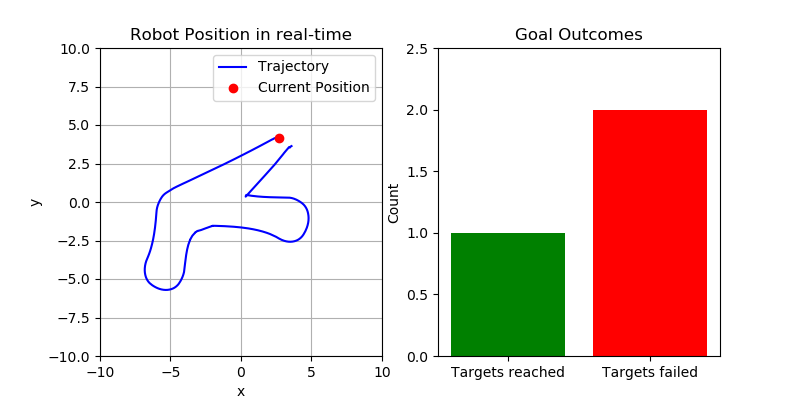

[INFO] [1746609514.165219, 2124.648000]: Goal sent: (0, 0)
[INFO] [1746609563.179955, 2162.842000]: Goal sent: (8, 8)
[INFO] [1746609567.333768, 2165.912000]: Cancelling the current goal.
[INFO] [1746609573.620946, 2170.616000]: Goal sent: (8, 8)
[INFO] [1746609576.512008, 2172.737000]: Goal sent: (8, 8)
[INFO] [1746610088.815903, 2566.313000]: Cancelling the current goal.


In [ ]:
# UI widgets
x_input = IntText(value = 0, description =  'X: ')
y_input = IntText(value = 0, description =  'Y: ')

send_btn = Button(description = "Send Goal", button_style = 'success')
cancel_btn = Button(description = "Cancel Goal", button_style = 'danger')
feedback_btn = Button(description = "FeedBack")

send_btn.on_click(send_goal)
cancel_btn.on_click(cancel_goal_btn)
feedback_btn.on_click(update_feedback_btn)

# Layout of the widgets
ui = VBox ([
    HBox([x_input, y_input]),
    HBox([send_btn, cancel_btn]),
    HBox([feedback_btn]),
    status_label,
    position_label,
    obstacle_label
])

display(ui)

fig, (ax, bar_ax) = plt.subplots(1, 2, figsize = (8, 4))
ani = FuncAnimation(fig, update_graph, interval = 1000)